## Trabajo Práctico Final - Aprendizaje de Máquina (CEIA)

### Grupo 3

**Integrantes:**
- Bernardo Pablo Eppenstein
- Gonzalo Martín Rodríguez
- Tómas Abraham
 

**Origen de la información:**

El data set que vamos a trabajar es obtenido de https://archive.ics.uci.edu/dataset/421/aps+failure+at+scania+trucks
que contiene 3 archivos aps_failure_test_set.csv, aps_failure_training_set.csv y aps_failure_description.txt

**Contexto**

El conjunto de datos se compone de información recopilada de camiones pesados ​​Scania durante su uso cotidiano. El sistema objeto de estudio es el sistema de aire a presión (APS), el cual genera aire comprimido utilizado para diversas funciones del camión, tales como el frenado y el cambio de marchas. La clase positiva del conjunto de datos comprende los fallos de un componente específico del sistema APS, mientras que la clase negativa incluye camiones con fallos en componentes ajenos a dicho sistema.

El conjunto de entrenamiento contiene un total de 60.000 ejemplos, de los cuales 59.000 pertenecen a la clase negativa y 1.000 a la clase positiva. El conjunto de prueba contiene 16.000 ejemplos. Hay 171 atributos por registro.

Los nombres de los atributos de los datos han sido anonimizados por razones de propiedad. Estos consisten tanto en contadores numéricos individuales como en histogramas formados por intervalos (o *bins*) con diferentes condiciones. Por lo general, los histogramas presentan condiciones de rango abierto en ambos extremos.

**Planteo del problema**

Los distintos mantenimientos tienen diversos costos. El Costo 1 del mantenimiento de un camión sin falla es 10 y el Costo 2 de un camión con falla es 500. Por lo tanto el objetivo es minimizar el costo total asociado a un modelo de predicción, que se calcula de la siguiente manera Costo Total = (Costo 1 * número de instancias 1) + (Costo 2 * número de instancias 2).
Por lo que se observa, el costo 1 es el costo asociado a la revisión innecesaria en un taller de un camión que no va a fallar, multiplicado por la cantidad de instancias 1, y el costo 2 se refiere al costo de no detectar un camión defectuoso, lo cual podría causar una avería, multiplicado por el número de instancias 2.


Cargamos los datos

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import psutil
import os
import time
%matplotlib inline

In [95]:
train = pd.read_csv('aps_failure_training_set.csv', skiprows=20, na_values='na')
test = pd.read_csv('aps_failure_test_set.csv', skiprows=20, na_values='na')

In [96]:
train.shape

(60000, 171)

### EDA

In [97]:
test.shape

(16000, 171)

El data set consiste solo de variables numericas.

Descartamos la constante

In [98]:
train.cd_000

0        1209600.0
1        1209600.0
2        1209600.0
3        1209600.0
4        1209600.0
           ...    
59995    1209600.0
59996    1209600.0
59997    1209600.0
59998    1209600.0
59999    1209600.0
Name: cd_000, Length: 60000, dtype: float64

Vemos los valores faltantes por columna

In [99]:
faltantes_por_columna = train.isnull().sum().sort_values(ascending=False)
print(faltantes_por_columna[faltantes_por_columna > 0])


br_000    49264
bq_000    48722
bp_000    47740
bo_000    46333
ab_000    46329
          ...  
by_000      473
ck_000      338
cj_000      338
ci_000      338
bt_000      167
Length: 169, dtype: int64


Como dijimos antes vamos a eliminar la variable constante e imputar los valores faltantes por la mediana, ya que es la que menos hace variar la distribución de la variable en los casos donde la misma es muy asimétrica.


In [100]:
from sklearn.impute import SimpleImputer

# cd_000 es constante (unico valor nulo) -> no aporta info, se descarta
train = train.drop(columns=['cd_000'])
test  = test.drop(columns=['cd_000'])

feature_cols = train.columns.drop('class')
imputer = SimpleImputer(strategy='median')
train[feature_cols] = imputer.fit_transform(train[feature_cols])
test[feature_cols] = imputer.transform(test[feature_cols])


In [101]:
train.shape

(60000, 170)


Verificamos la correlación entre features del data set, para ver si hay correlación fuerte entre algunas variables lo que nos permitiría eliminarlas. Tomamos un umbral de 0.9.


In [102]:
threshold = 0.9

# corremos la correlacion sobre las variables continuas originales, sin 'class'
corr_matrix = train[feature_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# de cada par con |r| > threshold, nos quedamos con una y descartamos la otra
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f'Columnas eliminadas por alta correlacion (> {threshold}): {len(to_drop)} de {len(feature_cols)}')
print(to_drop)

train = train.drop(columns=to_drop)
test  = test.drop(columns=to_drop)

print('shape train:', train.shape, 'shape test:', test.shape)


Columnas eliminadas por alta correlacion (> 0.9): 43 de 169
['am_0', 'an_000', 'ao_000', 'aq_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'bb_000', 'bg_000', 'bh_000', 'bi_000', 'bj_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'bt_000', 'bu_000', 'bv_000', 'by_000', 'cc_000', 'cf_000', 'ci_000', 'cn_004', 'cn_005', 'co_000', 'cq_000', 'cs_005', 'dc_000', 'dn_000', 'dp_000', 'dt_000', 'ed_000', 'ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004']
shape train: (60000, 127) shape test: (16000, 127)


In [103]:
train.shape

(60000, 127)

In [104]:
test.shape

(16000, 127)

In [105]:
X_train_full = train.drop(columns='class')
y_train_full = train['class'].map({'neg': 0, 'pos': 1})

X_test = test.drop(columns='class')
y_test = test['class'].map({'neg': 0, 'pos': 1})


In [106]:
X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape

((60000, 126), (60000,), (16000, 126), (16000,))

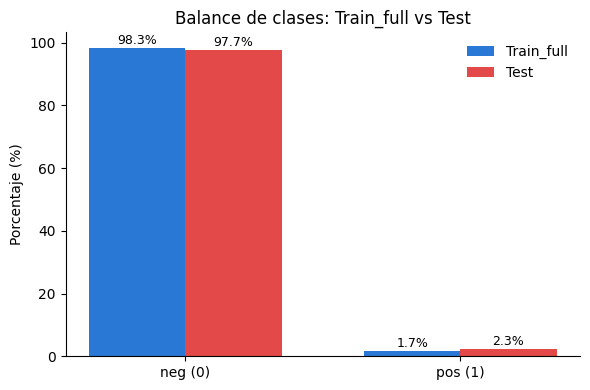

In [107]:
counts_train = y_train_full.value_counts(normalize=True).sort_index() * 100
counts_test  = y_test.value_counts(normalize=True).sort_index() * 100

labels = ['neg (0)', 'pos (1)']
x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars_train = ax.bar([i - width/2 for i in x], counts_train.values, width, label='Train_full', color='#2a78d6')
bars_test  = ax.bar([i + width/2 for i in x], counts_test.values, width, label='Test', color='#e34948')

ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Balance de clases: Train_full vs Test')
ax.legend(frameon=False)

for bars in [bars_train, bars_test]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.1f}%', xy=(b.get_x() + b.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Si bien el dataset presenta un marcado desbalance entre las clases, no se realizará un proceso de balanceo de los datos por las siguientes razones:

* Generación de datos sintéticos: si se optara por generar datos sintéticos de la clase minoritaria, sería necesario crear una cantidad muy elevada de nuevas observaciones para alcanzar una distribución equilibrada. Esto podría introducir información artificial en exceso y no resultaría conveniente para el análisis.

* Eliminación de datos de la clase mayoritaria: si, en cambio, se intentara balancear el dataset mediante *undersampling*, sería necesario eliminar una cantidad significativa de observaciones de la clase mayoritaria. Esto implicaría una pérdida considerable de información disponible para el entrenamiento de los modelos.

Por estos motivos, se conservará el dataset en su distribución original y se utilizarán modelos y estrategias de aprendizaje automático capaces de contemplar el desbalance entre las clases. De esta manera, se busca aprovechar la totalidad de los datos disponibles sin alterar artificialmente la distribución original del conjunto de datos.


Vamos a dividir el X_train_full y el y_train_full en un set de train y otro de validacion

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,  # importante por el desbalance
    random_state=42
)

In [109]:
X_train_full.shape, y_train_full.shape, X_train.shape, y_train.shape, X_val.shape, y_val.shape

((60000, 126), (60000,), (48000, 126), (48000,), (12000, 126), (12000,))

Antes de finalizar el EDA vamos a analizar si hay variables con baja correlación respecto a la variable Target para achicar la cantidad de datos a procesar por los modelos

In [110]:
# correlación de cada variable con la clase (point-biserial, ya que la clase es binaria 0/1)
corr_class = X_train_full.corrwith(y_train_full).sort_values(key=lambda s: s.abs(), ascending=False)

# Variables con correlación absoluta baja
corr_baja = corr_class[corr_class.abs() < 0.075]

print(corr_baja)

columnas_eliminar = corr_baja.index

# Eliminar columnas
X_train_full = X_train_full.drop(columns=columnas_eliminar)
X_train = X_train.drop(columns=columnas_eliminar)
X_test = X_test.drop(columns=columnas_eliminar)
X_val = X_val.drop(columns=columnas_eliminar)

cu_000    0.073613
ag_009    0.072081
cb_000    0.061901
cs_007    0.057203
ac_000   -0.050996
cy_000    0.050498
cp_000    0.049691
az_008    0.046269
bl_000    0.044402
as_000    0.043133
ay_009    0.042349
ct_000    0.032920
cr_000    0.031687
dz_000    0.030982
dh_000    0.030070
cz_000    0.025207
aj_000    0.023872
db_000   -0.016747
af_000    0.016250
ab_000    0.015084
ef_000    0.013650
ca_000    0.013132
eg_000    0.012809
ag_000    0.012353
dk_000    0.011875
ak_000    0.011753
ch_000    0.008404
ea_000    0.007372
ae_000    0.005541
dl_000   -0.003224
da_000   -0.002974
dm_000    0.002839
az_009    0.002535
dj_000   -0.001098
cs_009   -0.000540
ad_000   -0.000530
cs_008   -0.000076
dtype: float64


Se eliminan las variables que tienen baja correlación con la variable target para alivianar la carga del modelo.

Los datasets quedan entonces con las dimensiones:

In [111]:
X_train_full.shape, y_train_full.shape, X_train.shape, y_train.shape, X_val.shape, y_val.shape

((60000, 89), (60000,), (48000, 89), (48000,), (12000, 89), (12000,))

### Vamos a verificar cuáles son las variables con mayor correlación respecto del Target


aa_000    0.536978
ah_000    0.512991
bx_000    0.505529
ap_000    0.503651
ee_005    0.485831
ck_000    0.464198
ag_005    0.448212
cs_004    0.437519
ag_003    0.433050
az_005    0.432062
ba_000    0.430719
ee_006    0.415300
ay_008    0.409810
cn_003    0.406036
cs_003    0.391673
cn_001    0.390680
cs_002    0.372410
ag_004    0.371622
ag_006    0.368423
cn_002    0.367792
dtype: float64


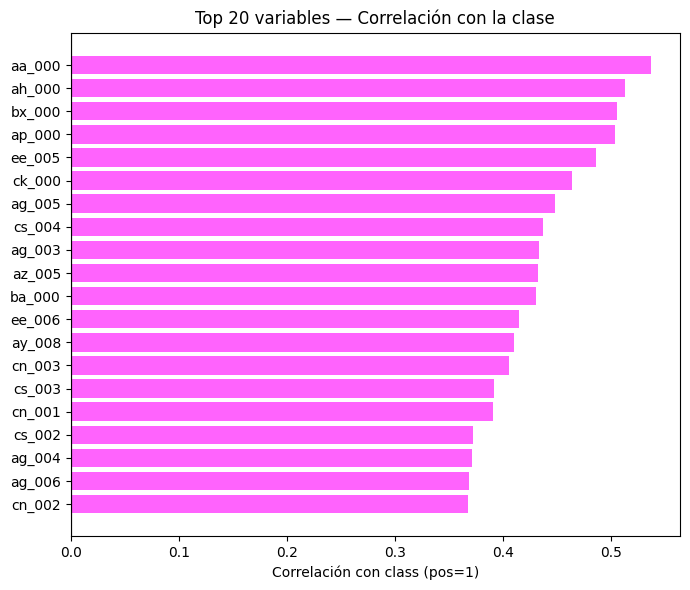

In [112]:
# correlación de cada variable con la clase (point-biserial, ya que la clase es binaria 0/1)
corr_class = X_train_full.corrwith(y_train_full).sort_values(key=lambda s: s.abs(), ascending=False)

top20_class = corr_class.head(20)
print(top20_class)

fig, ax = plt.subplots(figsize=(7, 6))
orden = top20_class.sort_values().index   # para que el gráfico quede ordenado de menor a mayor
valores = top20_class.loc[orden]
colores = ['#ff48fd' if v > 0 else '#007aff' for v in valores]
ax.barh(orden, valores, color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Correlación con class (pos=1)")
ax.set_title("Top 20 variables — Correlación con la clase")
plt.tight_layout()
plt.show()



 #### Función de costo
 Teniendo en cuenta que nuestra premisa es optimizar el costo de los mantenimiento mal clasificados como los FP y FN, y en los scoring de los modelos están las opciones que busquen por F1, recall y otros tipos de clasificadores también es posible colocar una función. Y creemos que es totalmente óptimo crear una función para que represente nuestro interés buscado.


Definimos una función de costo.

In [113]:
def costo(y_true, y_pred):
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return fn * 500 + fp * 10


### Vamos a aplicar un BASELINE con la variables de mayor correlacion con el target y tambien con las 5 variables que mejor correlacionan hacer una votacion 

In [114]:
# Baseline heurístico: umbral sobre aa_000 (variable con mayor correlación con la clase), sin entrenar ningún modelo
var_baseline = 'aa_000'

valor_neg = X_train.loc[y_train == 0, var_baseline]
valor_pos = X_train.loc[y_train == 1, var_baseline]
umbral_baseline = (valor_neg.median() + valor_pos.median()) / 2

y_pred_baseline = (X_test[var_baseline] > umbral_baseline).astype(int)


In [115]:
top5 = corr_class.abs().sort_values(ascending=False).head(5).index.tolist()

# umbral por variable: punto medio entre la mediana de la clase neg y la de la clase pos
umbrales_top5 = {}
for var in top5:
    valor_neg = X_train.loc[y_train == 0, var]
    valor_pos = X_train.loc[y_train == 1, var]
    umbrales_top5[var] = (valor_neg.median() + valor_pos.median()) / 2

print(umbrales_top5)

# para cada variable, 1 si supera su umbral, 0 si no
votos = pd.DataFrame({var: (X_test[var] > umbrales_top5[var]).astype(int) for var in top5})
conteo_votos = votos.sum(axis=1)

# predice falla si la mayoría (al menos 3 de 5) de las variables "alarman"
y_pred_baseline5 = (conteo_votos >= 3).astype(int)


{'aa_000': np.float64(300337.0), 'ah_000': np.float64(8957333.0), 'bx_000': np.float64(20649905.5), 'ap_000': np.float64(5375875.0), 'ee_005': np.float64(1432851.0)}


In [116]:
modelos = ["Baseline (umbral aa_000)", "Baseline (voto mayoría top5)"]
preds = [y_pred_baseline, y_pred_baseline5]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
    "Costo": [costo(y_test, yp) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (umbral aa_000),0.5377,0.8635,0.4184,0.752,50420
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840


### *Selección de algoritmos*

Los algoritmos seleccionados para analizar en nuestro modelo de clasificación están orientados principalmente por el fuerte desbalanceo que tenemos en el target. Y ya que de antemano es muy difícil predecir cuál se puede comportar mejor, aunque podemos intuir que posiblemente un ensamble se comporte mejor que un modelo más simple, solo lo vamos a saber corriendo los mismos.
Por lo tanto, de los modelos estudiados decidimos analizar Regresión Logística, SVC, Árboles de clasificación y Random Forest, ya que todos estos modelos tienen el hiperparámetro de balanceo de clases.


### Vamos a aplicar Regresión Logística


Vamos a aplicar el modelo regresión logística, por lo que vamos a aplicar GridSearchCV para seleccionar los hiperparámetros del modelo. Además vamos a definir un argumento que utiliza la función de costo para colocar en el scoring.
El modelo también requiere que se haga un escalado de las variables para que la ponderación sea la misma en todas ellas.


In [117]:
from sklearn.metrics import make_scorer

costo_scorer = make_scorer(costo, greater_is_better=False)


##### Búsqueda de hiperparámetros
Vamos a generar un pipeline que haga el escalado de los parámetros y corra el GridSearchCV.
Además agregamos código para que quede registrado el tiempo y la memoria utilizado en correr el modelo . Una forma de medir el costo de correr dicho modelo.


In [118]:
clf_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

hyperparams = {
    "model__C": [0.01, 0.1, 1],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced", {0: 1, 1: 50}]
}

grid = GridSearchCV(clf_logreg,
                    hyperparams,
                    refit=True,
                    cv=5,
                    scoring=costo_scorer,
                    n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid.best_params_)

Tiempo de búsqueda (GridSearchCV): 204.56 segundos
Memoria usada: 9.33 MB (antes: 428.01 MB, después: 437.34 MB)
{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [119]:
grid.best_params_

{'model__C': 0.01,
 'model__class_weight': 'balanced',
 'model__penalty': 'l1',
 'model__solver': 'liblinear'}

Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', para compensar el excesivo desbalance de los resultados. También usa regularización L1, que lo que hace es forzar muchos coeficientes a cero para anular variables que no aportan información. Además observamos que el valor de C es muy pequeño, lo que indica que la regularización es fuerte. Se utilizó el solver liblinear, que soporta regularización L1 y L2, y es el indicado para datasets chicos o medianos y para clasificación binaria.
También vemos que en el scoring se usó costo_scorer, que es una función que prioriza el costo de nuestro problema.

elegidos los parametros corremos el modelo

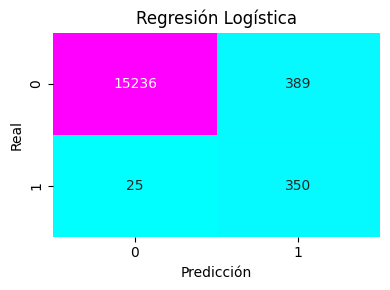

In [120]:
best_logreg = grid.best_estimator_

y_pred = best_logreg.predict(X_test)
cm_logreg = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Regresión Logística")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Vemos los resultados de las principales métricas.

In [121]:
TN, FP, FN, TP = cm_logreg.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Regresión Logística")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Costo total = {FP * 10 + FN * 500:.0f} (FP: {FP}, FN: {FN})")

Regresión Logística
Sensibilidad (Recall): 0.9333
Especificidad:         0.9751
Exactitud balanceada:  0.9542
Precisión:             0.4736
Recall:                0.9333
F1-score:              0.6284
Costo total = 16390 (FP: 389, FN: 25)


Como el modelo corre originalmente con un umbral de corte en 0.5. Vamos a utilizar el set de datos de validación para verificar si hay algún punto de corte que optimice mejor la función de costo.


In [122]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.01, 1.00, 0.05):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN     FP   costo
0     0.01   0  11798  117980
1     0.06   0   5135   51350
2     0.11   4   1550   17500
3     0.16   4    936   11360
4     0.21   6    672    9720
5     0.26   6    557    8570
6     0.31   6    482    7820
7     0.36   8    429    8290
8     0.41   9    393    8430
9     0.46  13    357   10070
10    0.51  13    331    9810
11    0.56  14    299    9990
12    0.61  15    273   10230
13    0.66  16    252   10520
14    0.71  20    226   12260
15    0.76  22    212   13120
16    0.81  25    195   14450
17    0.86  29    172   16220
18    0.91  31    150   17000
19    0.96  41    116   21660

Mejor umbral:
umbral       0.31
FN           6.00
FP         482.00
costo     7820.00
Name: 6, dtype: float64


Vamos a afinar la selección del umbral en torno al valor obtenido anteriormente.

In [123]:
# 1) Sacamos las probabilidades del modelo sobre la validación
#    predict_proba devuelve 2 columnas (prob de 0 y prob de 1), nos quedamos con la de clase 1 (pos)
probs = grid.best_estimator_.predict_proba(X_val)[:, 1]

# 2) Probamos distintos umbrales y calculamos el costo en cada uno
resultados = []

for umbral in np.arange(0.26, 0.37, 0.01):
    # convertimos probabilidad en predicción 0/1 según el umbral
    y_pred = (probs >= umbral).astype(int)
    
    # contamos falsos negativos y falsos positivos
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    
    # costo de negocio
    costo_i = fn * 500 + fp * 10
    
    resultados.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

# 3) Armamos una tabla para ver todo junto
tabla = pd.DataFrame(resultados)
print(tabla)

# 4) Nos quedamos con el umbral que minimiza el costo
mejor_fila = tabla.loc[tabla['costo'].idxmin()]
print("\nMejor umbral:")
print(mejor_fila)

    umbral  FN   FP  costo
0     0.26   6  557   8570
1     0.27   6  542   8420
2     0.28   6  524   8240
3     0.29   6  512   8120
4     0.30   6  496   7960
5     0.31   6  482   7820
6     0.32   7  464   8140
7     0.33   8  452   8520
8     0.34   8  442   8420
9     0.35   8  433   8330
10    0.36   8  429   8290

Mejor umbral:
umbral       0.31
FN           6.00
FP         482.00
costo     7820.00
Name: 5, dtype: float64


Seleccionado el mejor umbral de corte del modelo obtenemos nuevamente las métricas con el nuevo umbral de corte.

In [124]:
probs_test = grid.best_estimator_.predict_proba(X_test)[:, 1]
umbral_final = 0.29
y_pred_test = (probs_test >= umbral_final).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
costo_final = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final en test: {costo_final}")
print(classification_report(y_test, y_pred_test, digits=3))

TN=15001, FP=624, FN=12, TP=363
Costo final en test: 12240
              precision    recall  f1-score   support

           0      0.999     0.960     0.979     15625
           1      0.368     0.968     0.533       375

    accuracy                          0.960     16000
   macro avg      0.683     0.964     0.756     16000
weighted avg      0.984     0.960     0.969     16000



Observamos en las métricas que mejorando el corte del sistema mejoró el costo original de 16880 a 13780.


Vamos a graficar una curva ROC del modelo

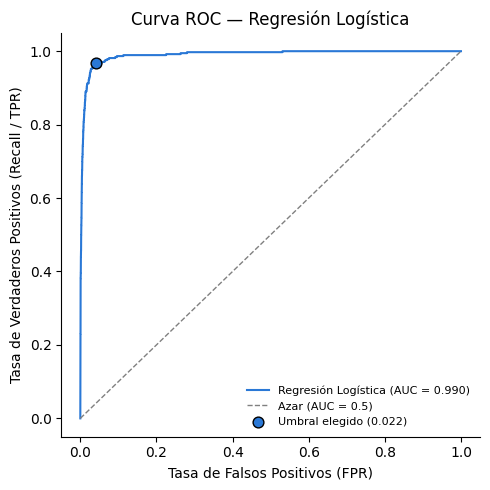

In [125]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


*Analisis de la features mas significativas*
Vamos a observar las variables que mayor probabilidad aporta para la  ocurrencia de fallas a medida que aumentan su intensidad (color magenta). Y en el caso de las variables (color azul) a medida que aumentan su intesidad la probabilidad de que el camion no falle aumentan

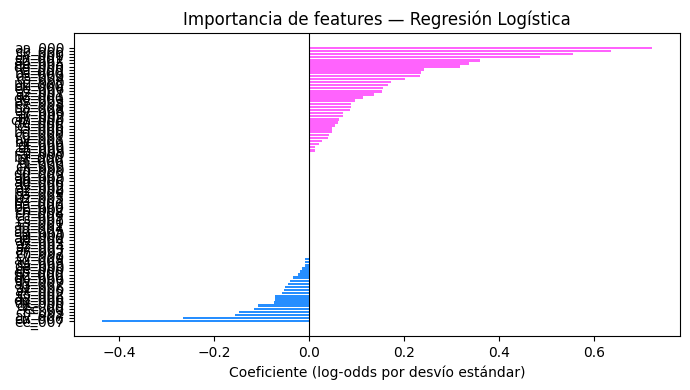

In [126]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
orden = np.argsort(coefs)

fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
feature_names = X_train.columns
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title("Importancia de features — Regresión Logística")
plt.tight_layout()
plt.show()

Vamos a afinar un poco mas la clasificacion para ver las variables mas significativas

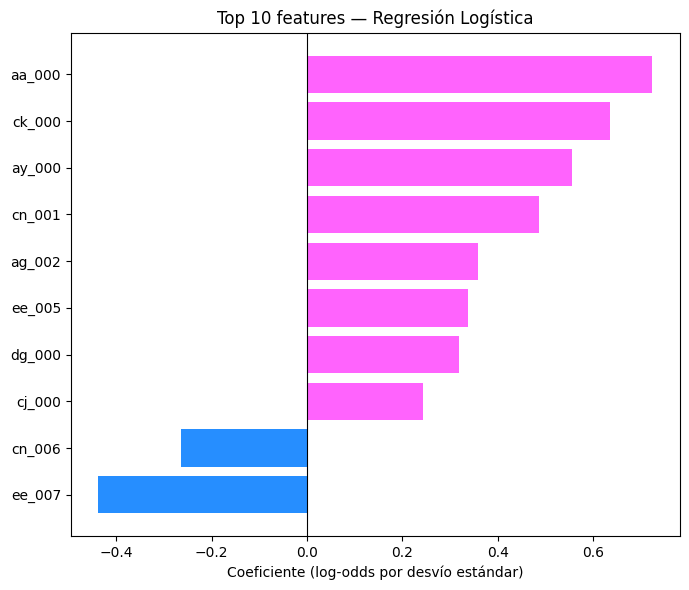

In [127]:
coefs = best_logreg.named_steps['model'].coef_.ravel()
feature_names = X_train.columns

n_top = 10
orden_abs = np.argsort(np.abs(coefs))[-n_top:]   # las n_top con mayor |coeficiente|
orden = orden_abs[np.argsort(coefs[orden_abs])]   # las reordena de menor a mayor para el gráfico

fig, ax = plt.subplots(figsize=(7, 6))
colores = ['#ff48fd' if c > 0 else '#007aff' for c in coefs[orden]]
ax.barh(np.array(feature_names)[orden], coefs[orden], color=colores, alpha=0.85)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel("Coeficiente (log-odds por desvío estándar)")
ax.set_title(f"Top {n_top} features — Regresión Logística")
plt.tight_layout()
plt.show()


#### Vemos una tabla de comparación de resultados modelos ejecutados hasta ahora.


In [128]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)"]
preds_final = [y_pred_baseline5, y_pred_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.808,39840
Regresión Logística (umbral 0.29),0.5330,0.9640,0.3678,0.968,12240


### Vamos a aplicar el modelo SVM

Vamos a aplicar el modelo de soporte vector machine. Con las consideraciones generales similares a las tenida en cuenta en el caso de Regrsion Logitica.

Antes de entrenar el data set completo y esto lleva mucho tiempo, vamos a realizar un muestreo del data set el con el cual vamos a seleccionar la aproximacion de  hiperparametros a utilizar.

In [129]:
X_train_muestra, _, y_train_muestra, _ = train_test_split(
    X_train, y_train,
    train_size=8000,
    stratify=y_train,
    random_state=42
)


In [130]:
X_train_muestra.shape, y_train_muestra.shape

((8000, 89), (8000,))

Vamos a aplicar un pipline de la muestra que hacer primero el escalado de las variables porque en este modelo si mide distancias y necesita que las magintudes esten todas escaladas. Ademas utilizar GridserachCV para la selección de hiperparámetros. Obviamente que también utilizamos la costo_scorer en el scoring.

In [131]:
from sklearn.svm import SVC

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])

hiper_svm = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.05, 0.1, 0.2],
    "model__gamma": ["scale", "auto"],   # se ignora automáticamente si kernel='linear'
    "model__class_weight": ["balanced"],
}


grid_svm = GridSearchCV(clf_svm,
                         hiper_svm,
                         refit=True,
                         cv=5,
                         scoring=costo_scorer,
                         n_jobs=-1)
grid_svm.fit(X_train_muestra, y_train_muestra)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.05, 0.1, ...], 'model__class_weight': ['balanced'], 'model__gamma': ['scale', 'auto'], 'model__kernel': ['linear', 'rbf']}"
,scoring,make_scorer(c...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [132]:
grid_svm.best_params_

{'model__C': 0.2,
 'model__class_weight': 'balanced',
 'model__gamma': 'scale',
 'model__kernel': 'rbf'}

Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', al igual que en los demás modelos, para compensar el excesivo desbalance de clases del problema. Se seleccionó el kernel rbf, lo que indica que la frontera de separación entre camiones con falla y sin falla no es puramente lineal,  El valor de gamma='scale' deja que scikit-learn calcule automáticamente, a partir de la varianza de las variables ya escaladas, hasta dónde llega la influencia de cada punto de entrenamiento sobre la frontera. Por último, C=0.1 es un valor relativamente bajo, lo que indica que el modelo prioriza un margen más amplio  por sobre clasificar perfectamente cada ejemplo de entrenamiento.

Ahora con esta seleccion de hiperparámetros vamos a correr el train del modelo completo.

Vamos a agregar codigo tambien para medir el tiempo utilizado en el entrenamiento y el costo de computo utilizado

In [133]:
clf_svm_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.1, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=42))
])



In [134]:
import time
import psutil
import os

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

clf_svm_final.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de entrenamiento: {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")


Tiempo de entrenamiento: 276.19 segundos
Memoria usada: -57.96 MB (antes: 459.18 MB, después: 401.23 MB)


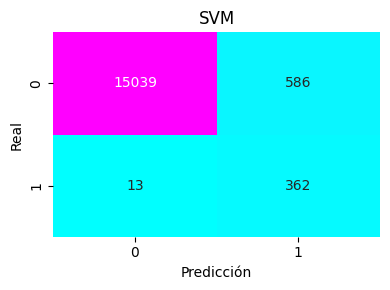

SVM (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9653
Especificidad:         0.9625
Exactitud balanceada:  0.9639
Precisión:             0.3819
Recall:                0.9653
F1-score:              0.5472
Costo total = 12360 (FP: 586, FN: 13)


In [135]:
y_pred_svm = clf_svm_final.predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_svm.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("SVM (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_svm)} (FP: {FP}, FN: {FN})")


Observamos los resultados de las métricas obtenidas

Ahora vamos a probar ajustar el umbal de 0,5 a ver si mejora incluso mas el ajuste para optimizar el costo. Esta prueba la vamos a hacer con paquete de validación.

In [136]:
probs_svm = clf_svm_final.predict_proba(X_val)[:, 1]

resultados_svm = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm = pd.DataFrame(resultados_svm)
print(tabla_svm)

mejor_fila_svm = tabla_svm.loc[tabla_svm['costo'].idxmin()]
print("\nMejor umbral SVM (barrido grueso):")
print(mejor_fila_svm)


    umbral   FN   FP  costo
0     0.05    9  424   8740
1     0.10    9  345   7950
2     0.15   10  315   8150
3     0.20   11  282   8320
4     0.25   13  255   9050
5     0.30   14  221   9210
6     0.35   19  163  11130
7     0.40  126   46  63460
8     0.45  148   33  74330
9     0.50  181   27  90770
10    0.55  186   19  93190
11    0.60  187   16  93660
12    0.65  190   13  95130
13    0.70  190   10  95100
14    0.75  194    6  97060
15    0.80  196    4  98040
16    0.85  197    4  98540
17    0.90  198    2  99020
18    0.95  199    1  99510

Mejor umbral SVM (barrido grueso):
umbral       0.1
FN           9.0
FP         345.0
costo     7950.0
Name: 1, dtype: float64


Queremos hacer zoom en el umbral 0,35 que cae de golpe los FN a pesar que no es el punto de menor costo hay alguno evento que ocurre que fallen muchos camiones en ese punto.

In [137]:
resultados_svm_zoom = []
for umbral in np.arange(0.25, 0.36, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_zoom.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

pd.DataFrame(resultados_svm_zoom)


,umbral,FN,FP,costo
0,0.25,13,255,9050
1,0.26,13,247,8970
2,0.27,13,243,8930
3,0.28,13,236,8860
4,0.29,13,231,8810
5,0.30,14,221,9210
6,0.31,15,215,9650
7,0.32,16,202,10020
8,0.33,16,192,9920
9,0.34,16,175,9750


Graficamos los valores obtenidos

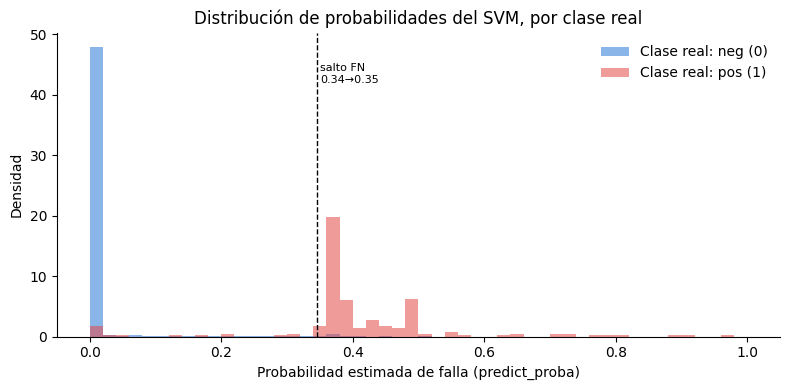

In [138]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.arange(0, 1.02, 0.02)

ax.hist(probs_svm[y_val == 0], bins=bins, density=True, alpha=0.55,
        color='#2a78d6', label='Clase real: neg (0)')
ax.hist(probs_svm[y_val == 1], bins=bins, density=True, alpha=0.55,
        color='#e34948', label='Clase real: pos (1)')

ax.axvline(0.345, color='k', linestyle='--', linewidth=1)
ax.text(0.35, ax.get_ylim()[1]*0.9, 'salto FN\n0.34→0.35', fontsize=8, va='top')

ax.set_xlabel('Probabilidad estimada de falla (predict_proba)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de probabilidades del SVM, por clase real')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

En el gráfico se muestra lo que creíamos ese umbral de probabilidades ocurre algun evento/os en particular que hace que muchos camiones fallen.

Ahora vamos a afinar los umbrales para ver si podemos mejorar el desempeño del costo

In [139]:
resultados_svm_fino = []
for umbral in np.arange(0.05, 0.21, 0.01):
    y_pred = (probs_svm >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_svm_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_svm_fino = pd.DataFrame(resultados_svm_fino)
print(tabla_svm_fino)

mejor_fila_svm_fino = tabla_svm_fino.loc[tabla_svm_fino['costo'].idxmin()]
print("\nMejor umbral SVM (barrido fino):")
print(mejor_fila_svm_fino)


    umbral  FN   FP  costo
0     0.05   9  424   8740
1     0.06   9  409   8590
2     0.07   9  386   8360
3     0.08   9  364   8140
4     0.09   9  357   8070
5     0.10   9  345   7950
6     0.11   9  338   7880
7     0.12   9  334   7840
8     0.13   9  327   7770
9     0.14  10  320   8200
10    0.15  10  315   8150
11    0.16  10  312   8120
12    0.17  10  304   8040
13    0.18  11  298   8480
14    0.19  11  292   8420
15    0.20  11  282   8320

Mejor umbral SVM (barrido fino):
umbral       0.13
FN           9.00
FP         327.00
costo     7770.00
Name: 8, dtype: float64


Con el mejor umbral seleccionado ahora lo corremos contra el paquete de test

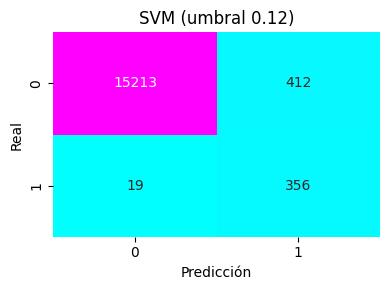

TN=15213, FP=412, FN=19, TP=356
Costo final SVM en test: 13620
              precision    recall  f1-score   support

           0      0.999     0.974     0.986     15625
           1      0.464     0.949     0.623       375

    accuracy                          0.973     16000
   macro avg      0.731     0.961     0.804     16000
weighted avg      0.986     0.973     0.978     16000



In [140]:
probs_svm_test = clf_svm_final.predict_proba(X_test)[:, 1]
umbral_final_svm = 0.12
y_pred_svm_test = (probs_svm_test >= umbral_final_svm).astype(int)

cm_svm_test = confusion_matrix(y_test, y_pred_svm_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_svm_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("SVM (umbral 0.12)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_svm_test.ravel()
costo_final_svm = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final SVM en test: {costo_final_svm}")
print(classification_report(y_test, y_pred_svm_test, digits=3))



Observamos los resultados de las métricas obtenidas. Vemos que la metrica mas importante que es el costo esta por encima del obtenido en Regresión Logistica.

Por ultimo graficamos la curva ROC del modelo

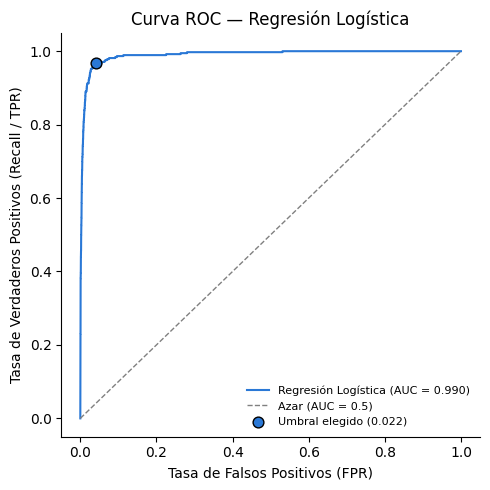

In [141]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, probs_test)
auc_log = auc(fpr_log, tpr_log)

tn_l, fp_l, fn_l, tp_l = confusion_matrix(y_test, y_pred_test).ravel()
fpr_op_log, tpr_op_log = fp_l / (fp_l + tn_l), tp_l / (tp_l + fn_l)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_log, tpr_log, color='#2a78d6', label=f'Regresión Logística (AUC = {auc_log:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_log], [tpr_op_log], color='#2a78d6', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.022)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Regresión Logística')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Ahora vamos a hacer una comparación de los modelos que se fueron utilizando.

In [142]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5330,0.9640,0.3678,0.9680,12240
SVM (umbral 0.12),0.6229,0.9615,0.4635,0.9493,13620


Observamos que por el momento el mejor modelo es el de regresión logistica. Al final de la corrida de todos los modelos se hará un análisis mas exaustivo de los resultados obtenidos.

##### *Calibración*

Como el objetivo buscado es optimizar la funcion de costo, el valor de predict_proba que movemos sirve para optimizar el corte de nuestro modelo y mejorar la clasificacion. Basicamente no usamos en ninguna caso el predict_proba como una magnitud en si misma, por ejemplo "estimar el porcentaje de la flota que va a fallar", en ese caso si deberiamos calibrar el valor.
En ambos casos la calibración es mala porque en ambos modelos se utilizo la funcion costo_scorer y ademas se utilizo class_weight='balanced' y esto hace que el modelo entrene como si las clases estuvieran mas equilibradas de lo que lo estan realmente.

Graficamos las curvas de calibracion de ambos modelos, solo para observarlas pero en nuestro caso no es de utilidad para nuestro problema.

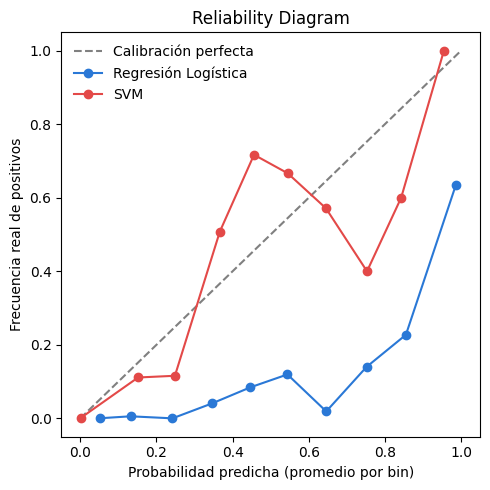

Brier score logreg: 0.025474039868867464
Brier score SVM: 0.012295842794792483


In [143]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos_log, mean_pred_log = calibration_curve(y_test, probs_test, n_bins=10)
frac_pos_svm, mean_pred_svm = calibration_curve(y_test, probs_svm_test, n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Calibración perfecta')
ax.plot(mean_pred_log, frac_pos_log, marker='o', color='#2a78d6', label='Regresión Logística')
ax.plot(mean_pred_svm, frac_pos_svm, marker='o', color='#e34948', label='SVM')
ax.set_xlabel('Probabilidad predicha (promedio por bin)')
ax.set_ylabel('Frecuencia real de positivos')
ax.set_title('Reliability Diagram')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Brier score logreg:", brier_score_loss(y_test, probs_test))
print("Brier score SVM:", brier_score_loss(y_test, probs_svm_test))

#### Arboles de clasificacion

En este tipo de modelo no necesitamos escalar los valores de los features. Asi que vamos a hacer una seleccion de hiperparametros con GridsearchCV para seleccionar los mejores hiperparametros

Como vemos la funcion de scoring vamos a usar nuevamente la funcion de costo de nuestro problema.

In [144]:
from sklearn.tree import DecisionTreeClassifier

hiper_tree = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)
grid_tree.fit(X_train, y_train)

c:\Users\Gonzalo Rodriguez\OneDrive\Documentos\Especializacion en IA -CEIA\Aprendizaje de maquina\Repositorio\aprMaqI_CEIA\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5, ...], 'min_samples_split': [2, 10, ...]}"
,scoring,make_scorer(c...hod='predict')
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [145]:
grid_tree.best_params_


{'class_weight': 'balanced',
 'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

Vamos a volver a entrenar los parametros ya que max_depth quedo en el valor minio de 3 que era lo que habiamos puestos como piso de profundidad. Tambien agregamos a script para medir tiempo y memoria utilizada para la selección de hiperparámetros.

In [146]:

hiper_tree = {
    "max_depth": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                          hiper_tree,
                          refit=True,
                          cv=5,
                          scoring=costo_scorer,
                          n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)   # MB
inicio = time.perf_counter()

grid_tree.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)  # MB

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_tree.best_params_)


Tiempo de búsqueda (GridSearchCV): 87.50 segundos
Memoria usada: -7.30 MB (antes: 452.24 MB, después: 444.94 MB)
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


Vemos que los hiperparámetros elegidos utilizan class_weight='balanced', siguiendo el mismo patrón que en los demás modelos. El max_depth=4 muestra que el árbol no necesita mucha profundidad para capturar la separación entre camiones con falla y sin falla. Por último, min_samples_leaf=1 y min_samples_split=2 quedaron en sus valores por defecto, los menos restrictivos posibles: como la profundidad ya está bastante limitada, no hace falta que estos otros parámetros aporten regularización adicional.



Vamos a entrenar el paquete de test y ver los resultados obtenidos

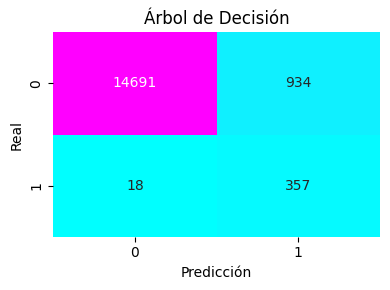

Árbol de Decisión (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9520
Especificidad:         0.9402
Exactitud balanceada:  0.9461
Precisión:             0.2765
Recall:                0.9520
F1-score:              0.4286
Costo total = 18340 (FP: 934, FN: 18)


In [147]:
best_tree = grid_tree.best_estimator_

y_pred_tree = best_tree.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_tree.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Árbol de Decisión (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_tree, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_tree)} (FP: {FP}, FN: {FN})")


Vamos a utilzar el set de validacion para verificar cual umbral de p_proba mejora el trade off para la funciona de costo que tenemos

In [148]:
probs_tree = best_tree.predict_proba(X_val)[:, 1]
print(f"Valores distintos de probabilidad: {np.unique(probs_tree)}")

resultados_tree = []
for umbral in np.arange(0.05, 1.00, 0.05):
    y_pred = (probs_tree >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_tree.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_tree = pd.DataFrame(resultados_tree)
print(tabla_tree)

mejor_fila_tree = tabla_tree.loc[tabla_tree['costo'].idxmin()]
print("\nMejor umbral árbol:")
print(mejor_fila_tree)


Valores distintos de probabilidad: [0.         0.01930673 0.15580986 0.25877193 0.52128514 0.53881279
 0.76623377 0.84841222 0.86425781 0.92367906 0.9661957  0.97520661]
    umbral  FN    FP  costo
0     0.05   6  1044  13440
1     0.10   6  1044  13440
2     0.15   6  1044  13440
3     0.20   7   811  11610
4     0.25   7   811  11610
5     0.30   7   763  11130
6     0.35   7   763  11130
7     0.40   7   763  11130
8     0.45   7   763  11130
9     0.50   7   763  11130
10    0.55   9   581  10310
11    0.60   9   581  10310
12    0.65   9   581  10310
13    0.70   9   581  10310
14    0.75   9   581  10310
15    0.80   9   565  10150
16    0.85  16   498  12980
17    0.90  25   389  16390
18    0.95  25   373  16230

Mejor umbral árbol:
umbral        0.8
FN            9.0
FP          565.0
costo     10150.0
Name: 15, dtype: float64


Ahora vamos a correr el data set de test con p_proba modificado el umbal a 0,8

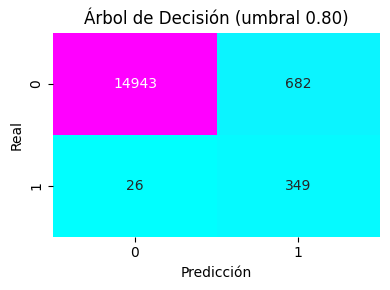

TN=14943, FP=682, FN=26, TP=349
Costo final árbol en test: 19820
              precision    recall  f1-score   support

           0      0.998     0.956     0.977     15625
           1      0.339     0.931     0.496       375

    accuracy                          0.956     16000
   macro avg      0.668     0.944     0.737     16000
weighted avg      0.983     0.956     0.966     16000



In [149]:
probs_tree_test = best_tree.predict_proba(X_test)[:, 1]
umbral_final_tree = 0.80
y_pred_tree_test = (probs_tree_test >= umbral_final_tree).astype(int)

cm_tree_test = confusion_matrix(y_test, y_pred_tree_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_tree_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Árbol de Decisión (umbral 0.80)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_tree_test.ravel()
costo_final_tree = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final árbol en test: {costo_final_tree}")
print(classification_report(y_test, y_pred_tree_test, digits=3))


Observamos los resultados obtenidos y vemos que la métrica de costo no mejora la de regresión Logística que es la mejor hasta ahora.

Vamos a graficar la curva ROC

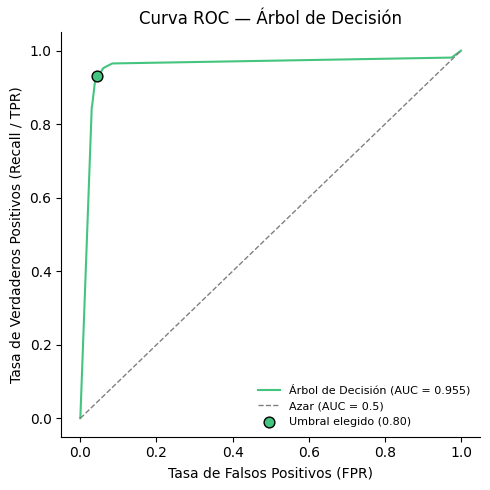

In [150]:
fpr_tree, tpr_tree, _ = roc_curve(y_test, probs_tree_test)
auc_tree = auc(fpr_tree, tpr_tree)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tree_test).ravel()
fpr_op_tree, tpr_op_tree = fp_t / (fp_t + tn_t), tp_t / (tp_t + fn_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_tree, tpr_tree, color='#44c57f', label=f'Árbol de Decisión (AUC = {auc_tree:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_tree], [tpr_op_tree], color='#44c57f', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.80)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Árbol de Decisión')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### Por ultimo agregamos una tabla comparativa de los modelos utilizados

In [151]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5330,0.9640,0.3678,0.9680,12240
SVM (umbral 0.12),0.6229,0.9615,0.4635,0.9493,13620
Árbol de Decisión (umbral 0.80),0.4964,0.9435,0.3385,0.9307,19820


#### Random Forest

Vamos a seleccionar los hiperparametos para este modelo con GridsearchCV. Manteniendo los mismos principio que árbol de clasificación. También se agrega código para medir tiempo y memoría utilizada.

In [152]:
from sklearn.ensemble import RandomForestClassifier

hiper_rf = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [1, 5],
    "class_weight": [None, "balanced", "balanced_subsample"],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                        hiper_rf,
                        refit=True,
                        cv=5,
                        scoring=costo_scorer,
                        n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf.best_params_)


Tiempo de búsqueda (GridSearchCV): 912.48 segundos
Memoria usada: 16.67 MB (antes: 450.55 MB, después: 467.21 MB)
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}


Como varios hiperparametros cayeron en los bordes de las opciones de prueba. Vamos a correrlo de nuevos con nuevos valores de hiperparametros, solo vamos a dejar fijo el class_weight+'balanced' que ya quedo definido.

In [153]:
hiper_rf_v2 = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [5, 10],
    "class_weight": ["balanced"],
}

grid_rf_v2 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v2,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v2.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v2.best_params_)


Tiempo de búsqueda (GridSearchCV): 154.26 segundos
Memoria usada: 0.18 MB (antes: 468.01 MB, después: 468.19 MB)
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 50}


Volvemos a correrlo nuevamente ya que por ejemplo el parámetro de max_depth tambien esta en el límite de las opciones ofrecidas para probar

In [154]:
hiper_rf_v3 = {
    "n_estimators": [150, 200, 300],
    "max_depth": [5, 6, 8, 10],
    "min_samples_leaf": [10, 15, 20],
    "class_weight": ["balanced"],
}

grid_rf_v3 = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                           hiper_rf_v3,
                           refit=True,
                           cv=5,
                           scoring=costo_scorer,
                           n_jobs=-1)

proceso = psutil.Process(os.getpid())
memoria_antes = proceso.memory_info().rss / (1024 ** 2)
inicio = time.perf_counter()

grid_rf_v3.fit(X_train, y_train)

fin = time.perf_counter()
memoria_despues = proceso.memory_info().rss / (1024 ** 2)

print(f"Tiempo de búsqueda (GridSearchCV): {fin - inicio:.2f} segundos")
print(f"Memoria usada: {memoria_despues - memoria_antes:.2f} MB (antes: {memoria_antes:.2f} MB, después: {memoria_despues:.2f} MB)")
print(grid_rf_v3.best_params_)


Tiempo de búsqueda (GridSearchCV): 905.10 segundos
Memoria usada: -245.49 MB (antes: 468.21 MB, después: 222.73 MB)
{'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 150}


"Vamos a analizar los hiperparámetros seleccionados. class_weight='balanced', al igual que en todos los modelos, se utiliza para compensar el excesivo desbalance que tiene nuestro set de datos. Con max_depth=5 vemos que el modelo no necesita mucha profundidad para capturar la separación de resultados. El min_samples_leaf=10 es bastante restrictivo, evita que los árboles creen hojas muy específicas. n_estimators=150 es una cantidad de árboles intermedia, no muy chica pero tampoco excesivamente grande (lo cual implicaría un costo computacional mayor). También usamos scoring=costo_scorer, que es nuestra función de costo del problema."

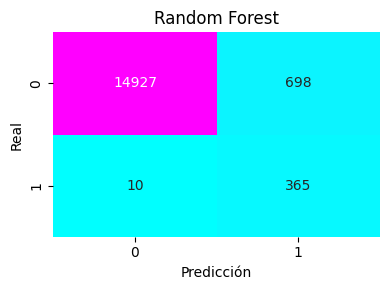

Random Forest (umbral 0.5, sin ajustar)
Sensibilidad (Recall): 0.9733
Especificidad:         0.9553
Exactitud balanceada:  0.9643
Precisión:             0.3434
Recall:                0.9733
F1-score:              0.5076
Costo total = 11980 (FP: 698, FN: 10)


In [155]:
best_rf = grid_rf_v3.best_estimator_

y_pred_rf = best_rf.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm_rf.ravel()
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Random Forest (umbral 0.5, sin ajustar)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Recall:                {recall_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"Costo total = {costo(y_test, y_pred_rf)} (FP: {FP}, FN: {FN})")


Vamos a probar con el set de validación modificar el umbral para ver si mejora el costo

In [156]:
probs_rf = best_rf.predict_proba(X_val)[:, 1]

resultados_rf = []
for umbral in np.arange(0.01, 1.00, 0.05):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf = pd.DataFrame(resultados_rf)
print(tabla_rf)

mejor_fila_rf = tabla_rf.loc[tabla_rf['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido amplio):")
print(mejor_fila_rf)


    umbral   FN     FP   costo
0     0.01    0  11800  118000
1     0.06    2   1752   18520
2     0.11    2   1291   13910
3     0.16    2   1095   11950
4     0.21    4    965   11650
5     0.26    4    879   10790
6     0.31    5    807   10570
7     0.36    5    729    9790
8     0.41    5    665    9150
9     0.46    6    604    9040
10    0.51    6    546    8460
11    0.56    9    497    9470
12    0.61    9    445    8950
13    0.66   12    404   10040
14    0.71   20    360   13600
15    0.76   25    313   15630
16    0.81   31    250   18000
17    0.86   41    178   22280
18    0.91   69    113   35630
19    0.96  114     21   57210

Mejor umbral Random Forest (barrido amplio):
umbral       0.51
FN           6.00
FP         546.00
costo     8460.00
Name: 10, dtype: float64


Hacemos un ajuste fino del umbral

In [157]:
resultados_rf_fino = []
for umbral in np.arange(0.41, 0.62, 0.01):
    y_pred = (probs_rf >= umbral).astype(int)
    fn = ((y_val == 1) & (y_pred == 0)).sum()
    fp = ((y_val == 0) & (y_pred == 1)).sum()
    costo_i = fn * 500 + fp * 10
    resultados_rf_fino.append({'umbral': umbral, 'FN': fn, 'FP': fp, 'costo': costo_i})

tabla_rf_fino = pd.DataFrame(resultados_rf_fino)
print(tabla_rf_fino)

mejor_fila_rf_fino = tabla_rf_fino.loc[tabla_rf_fino['costo'].idxmin()]
print("\nMejor umbral Random Forest (barrido fino):")
print(mejor_fila_rf_fino)


    umbral  FN   FP  costo
0     0.41   5  665   9150
1     0.42   5  653   9030
2     0.43   6  642   9420
3     0.44   6  631   9310
4     0.45   6  613   9130
5     0.46   6  604   9040
6     0.47   6  595   8950
7     0.48   6  579   8790
8     0.49   6  572   8720
9     0.50   6  562   8620
10    0.51   6  546   8460
11    0.52   6  538   8380
12    0.53   6  528   8280
13    0.54   8  519   9190
14    0.55   8  502   9020
15    0.56   9  497   9470
16    0.57   9  484   9340
17    0.58   9  475   9250
18    0.59   9  466   9160
19    0.60   9  457   9070
20    0.61   9  445   8950

Mejor umbral Random Forest (barrido fino):
umbral       0.53
FN           6.00
FP         528.00
costo     8280.00
Name: 12, dtype: float64


Un dato importante para destacar es que el umbral que mejor costo nos da haciendo el ajuste fino es el mismo umbral que el modelo toma por defecto en 0.5.

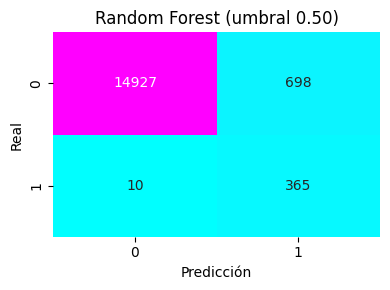

TN=14927, FP=698, FN=10, TP=365
Costo final Random Forest en test: 11980
              precision    recall  f1-score   support

           0      0.999     0.955     0.977     15625
           1      0.343     0.973     0.508       375

    accuracy                          0.956     16000
   macro avg      0.671     0.964     0.742     16000
weighted avg      0.984     0.956     0.966     16000



In [158]:
probs_rf_test = best_rf.predict_proba(X_test)[:, 1]
umbral_final_rf = 0.50
y_pred_rf_test = (probs_rf_test >= umbral_final_rf).astype(int)

cm_rf_test = confusion_matrix(y_test, y_pred_rf_test)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_rf_test, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Random Forest (umbral 0.50)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf_test.ravel()
costo_final_rf = fn * 500 + fp * 10

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Costo final Random Forest en test: {costo_final_rf}")
print(classification_report(y_test, y_pred_rf_test, digits=3))


Observamos los resultados obtenidos, en este modelo si se mejora el costo asociado.

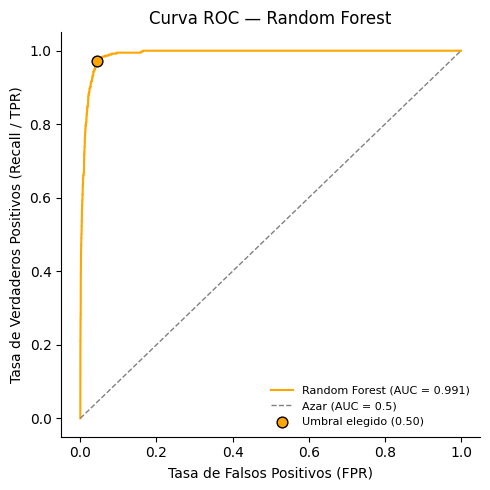

In [159]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf_test)
auc_rf = auc(fpr_rf, tpr_rf)

tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test, y_pred_rf_test).ravel()
fpr_op_rf, tpr_op_rf = fp_r / (fp_r + tn_r), tp_r / (tp_r + fn_r)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_rf, tpr_rf, color='#ffa600', label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar (AUC = 0.5)')
ax.scatter([fpr_op_rf], [tpr_op_rf], color='#ffa600', edgecolor='k', zorder=5, s=60,
           label='Umbral elegido (0.50)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall / TPR)')
ax.set_title('Curva ROC — Random Forest')
ax.legend(frameon=False, loc='lower right', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


Vamos a realizar un grafico para observar cuales son las features que mayor informacion le aportan al modelo random forest clasificar si un camion va a fallar.

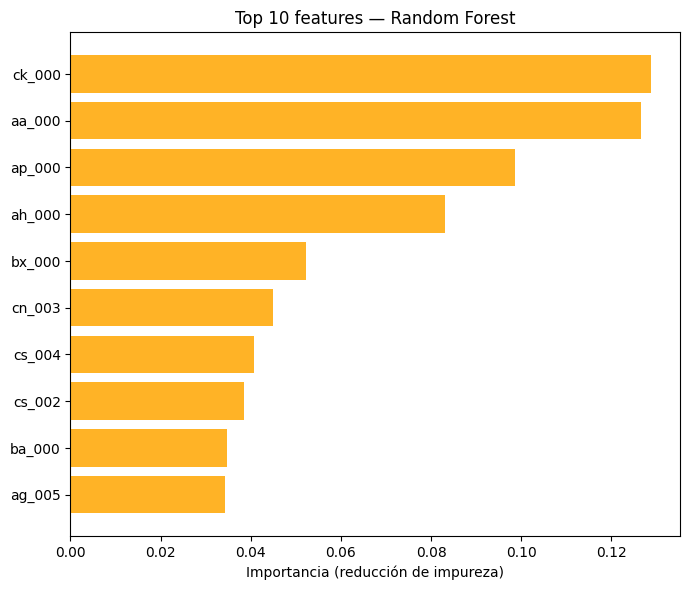

In [160]:
importancias = best_rf.feature_importances_
feature_names = X_train.columns

n_top = 10
orden = np.argsort(importancias)[-n_top:]   # las n_top con mayor importancia

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(np.array(feature_names)[orden], importancias[orden], color='#ffa600', alpha=0.85)
ax.set_xlabel("Importancia (reducción de impureza)")
ax.set_title(f"Top {n_top} features — Random Forest")
plt.tight_layout()
plt.show()


Observamos que 8 de las 10 variables se corresponden con las que mayor correlacion tienen con el target. Y vemos otras 2 variables que no tienen realación monotona con el target seguramente en combinacion con otras variables aportan mas valor para la clasificacion

### Por utlimo vamos a ver un cuadro comparativo de todos los modelos entrenados

In [161]:
modelos_final = ["Baseline (voto mayoría top5)", "Regresión Logística (umbral 0.29)", "SVM (umbral 0.12)", "Árbol de Decisión (umbral 0.80)", "Random Forest (umbral 0.50)"]
preds_final = [y_pred_baseline5, y_pred_test, y_pred_svm_test, y_pred_tree_test, y_pred_rf_test]

df_cmp_final = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds_final],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds_final],
    "Costo": [costo(y_test, yp) for yp in preds_final],
}, index=pd.Index(modelos_final))

df_cmp_final.round(4)


,F1-score,Exactitud balanceada,Precisión,Recall,Costo
Baseline (voto mayoría top5),0.5706,0.8917,0.4410,0.8080,39840
Regresión Logística (umbral 0.29),0.5330,0.9640,0.3678,0.9680,12240
SVM (umbral 0.12),0.6229,0.9615,0.4635,0.9493,13620
Árbol de Decisión (umbral 0.80),0.4964,0.9435,0.3385,0.9307,19820
Random Forest (umbral 0.50),0.5076,0.9643,0.3434,0.9733,11980


##### Conclusion de resultados:
Vemos que el modelo que mejor performa según nuestro objetivo primordial, que es minimizar el costo, es Random Forest, con un costo de 11.980, y como segundo modelo que mejor performa está Regresión Logística, con un costo de 12.240.

Al observar los resultados vemos que los F1-score dan valores muy bajos, ya que detectar un Falso Positivo no resulta muy costoso para la función de costo. Respecto a la exactitud balanceada, a pesar de no tener en cuenta la función de costo, nos da un buen indicador: el mejor valor lo tiene Random Forest, lo cual nos dice que el modelo tiene una buena relación (sensibilidad + especificidad)/2. Y el Recall, obviamente, también es mejor en Random Forest, ya que tiene muy en cuenta los Falsos Negativos, que son los que mayor costo tienen en la función de costo que es nuestro objetivo.

Creemos que a pesar de haber trabajado con un dataset desbalanceado se logró encontrar la manera de entrenar un modelo que sea útil para el problema en cuestión. En nuestro caso expresamente fue no dejar pasar Falsos Negativos ya que esto implicaría un sistema con falla que termina llegando a mantenimiento luego de haber fallado (no logra llegar al mantenimiento preventivamente).

Posiblemente haciendo una ingeniería de features mas exhaustiva y aplicando algunos otros modelos de bagging o boosting se puede mejor el resultado.

En este trabajo se logró implementar una aplicación de IA a un problema real de una empresa muy importante para la industria. Nos resulta gratificante poder ver aplicados los conocimientos adquiridos en lo que va del posgrado en un caso real, en donde se puede achicar notablemente la pérdida económica de una entidad real gracias a lo realizado.

Un dato de color a tener en cuenta en al información de problema se muestra que en el 2016 se hizo un concurso con este data set donde ganó una pareja de comapañeros cuyo costo obtenido fue 9920 y el puesto tercero fue un grupo de  4 compañeros que obtuvieron un costo de 11480. O sea que con el modelo entrenado estamos bastante cerca del 3º puesto.